In [4]:
from typing import Annotated
from typing import Literal
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL
from typing_extensions import TypedDict
from langgraph.graph import MessagesState, END, StateGraph, START
from langgraph.types import Command
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.prebuilt import create_react_agent

C:\Users\LOQ\AppData\Local\Temp\ipykernel_22216\4094062135.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
C:\Users\LOQ\AppData\Local\Temp\ipykernel_22216\4094062135.py:5: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.utilities import PythonREPL


## Loading the model

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
os.environ["GROQ_API_KEY"] = GROQ_API_KEY

In [6]:
from langchain_groq import ChatGroq
groq_model = ChatGroq(model = "llama-3.1-8b-instant", api_key = GROQ_API_KEY)

In [7]:
def clean_text(text):
    import re
    clean_text = re.sub(r"<think>. *?</think>\s*", "", text, flags = re.DOTALL)
    return clean_text

In [8]:
response = groq_model.invoke("Hi")
clean_text(response.content)

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [9]:
tavily_tool = TavilySearchResults()

C:\Users\LOQ\AppData\Local\Temp\ipykernel_22216\583234793.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults()


In [10]:
tavily_tool.invoke("What is GDP?")

[{'title': 'Gross domestic product - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/Gross_domestic_product',
  'content': 'Gross domestic product (GDP) is a monetary measure of the total market value of all of the final goods and services which are produced and rendered during a specific period of time (usually a year) by a country or countries. GDP is often used to measure the economic activity of a country or region. The major components of GDP are consumption, government spending, net exports (exports minus imports), and investment. Changing any of these factors can increase the size of the economy. For example, population growth through mass immigration can raise consumption and demand for public services, thereby contributing to GDP growth. However, GDP is not a measure of overall standard of living or well-being, as it does not account for how income is distributed among the population. A country may [...] GDP is often used as a metric for international comparisons as well a

In [11]:
code = """"
x = 5
y = x*2
print(y)
"""

In [12]:
repl = PythonREPL()

In [13]:
repl.run(code)

Python REPL can execute arbitrary code. Use with caution.


'SyntaxError(\'unterminated string literal (detected at line 1)\', (\'<string>\', 1, 1, \'"\', 1, 1))'

In [14]:
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code and do math. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""

    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    
    return f"Successfully executed: {code} Stdout: {result}"

In [15]:
print(python_repl_tool.invoke(code))

Successfully executed: "
x = 5
y = x*2
print(y)
 Stdout: SyntaxError('unterminated string literal (detected at line 1)', ('<string>', 1, 1, '"', 1, 1))


In [16]:
members = ["researcher", "coder"]

In [17]:
options = members+ ["FINISH"]

In [18]:
options

['researcher', 'coder', 'FINISH']

In [19]:
class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH"""
    next: Literal['researcher', 'coder', 'FINISH']

In [20]:
class State(MessagesState):
    next: str

In [21]:
system_prompt = f""""
You are a supervisor managing a conversation between the workers: {members}.
Given a user request, respond with which worker should act next: 'researcher', 'coder', or 'FINISH'.
If the task requires math or computation (for example numeric calculations, square roots, or executing code), choose 'coder'.
The researcher may use the TavilySearchResults tool for factual research but must not perform math.
Each worker will perform a task and return results and status. When finished, respond with FINISH.
"""

In [22]:
[{"role": "system", "content": system_prompt},]

[{'role': 'system',
  'content': '"\nYou are a supervisor managing a conversation between the workers: [\'researcher\', \'coder\'].\nGiven a user request, respond with which worker should act next: \'researcher\', \'coder\', or \'FINISH\'.\nIf the task requires math or computation (for example numeric calculations, square roots, or executing code), choose \'coder\'.\nThe researcher may use the TavilySearchResults tool for factual research but must not perform math.\nEach worker will perform a task and return results and status. When finished, respond with FINISH.\n'}]

In [23]:
# Initial conversation state: use the 'messages' key expected by the graph
state = {"messages": []}

In [24]:
state["messages"]

[]

In [25]:
[{"role": "system", "content": system_prompt},] + state["messages"]

[{'role': 'system',
  'content': '"\nYou are a supervisor managing a conversation between the workers: [\'researcher\', \'coder\'].\nGiven a user request, respond with which worker should act next: \'researcher\', \'coder\', or \'FINISH\'.\nIf the task requires math or computation (for example numeric calculations, square roots, or executing code), choose \'coder\'.\nThe researcher may use the TavilySearchResults tool for factual research but must not perform math.\nEach worker will perform a task and return results and status. When finished, respond with FINISH.\n'}]

In [26]:
def supervisor_node(state: State) -> Command[Literal["researcher", "coder", "__end__"]]:
    messages = [SystemMessage(content=system_prompt)] + state["messages"]

    response = groq_model.with_structured_output(Router).invoke(messages)

    goto = response["next"]

    print("below my goto********************")
    print(goto)

    if goto == "FINISH":
        return Command(
            goto=END,
            update={"next": "FINISH"}
        )

    return Command(
        goto=goto,
        update={
            "messages": state["messages"],
            "next": goto
        }
    )

In [27]:
def research_node(state: State) -> Command[Literal["supervisor"]]:
    research_agent = create_react_agent(groq_model, tools = [tavily_tool], prompt = "You are a researcher. DO NOT do any math.")
    result = research_agent.invoke(state)

    return Command(
        update = {
            "messages": [
                HumanMessage(content = result["messages"][-1].content, name = "researcher")
            ]
        },
        goto = "supervisor",
    )

In [28]:
def code_node(state: State) -> Command[Literal["supervisor"]]:
    code_agent = create_react_agent(groq_model, tools = [python_repl_tool])
    result = code_agent.invoke(state)

    return Command(
        update = {
            "messages": [
                HumanMessage(content = result["messages"][-1].content, name = "coder")
            ]
        },
        goto = "supervisor",
    )

In [29]:
graph = StateGraph(State)

In [30]:
graph.add_node("supervisor", supervisor_node)

In [31]:
graph.add_node("researcher", research_node)

In [32]:
graph.add_node("coder", code_node)

In [33]:
graph.add_edge(START, "supervisor")

In [34]:
app = graph.compile()

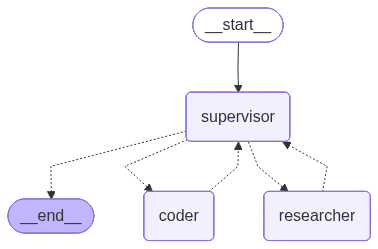

In [35]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [36]:
user_messages = [
    HumanMessage(content="What's the square root of 42?")
]

for event in app.stream(
    {"messages": user_messages},
    stream_mode="updates"
):
    print(event)
    print("-" * 50)

below my goto********************
coder
{'supervisor': {'messages': [HumanMessage(content="What's the square root of 42?", additional_kwargs={}, response_metadata={}, id='865561d7-f760-4026-9b6d-76c07bd77f6d')], 'next': 'coder'}}
--------------------------------------------------


C:\Users\LOQ\AppData\Local\Temp\ipykernel_22216\58754772.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent = create_react_agent(groq_model, tools = [python_repl_tool])


{'coder': {'messages': [HumanMessage(content='The square root of 42 is approximately 6.48.', additional_kwargs={}, response_metadata={}, name='coder', id='c4efc264-6a5b-471d-93ac-7236da2b4e2c')]}}
--------------------------------------------------
below my goto********************
coder
{'supervisor': {'messages': [HumanMessage(content="What's the square root of 42?", additional_kwargs={}, response_metadata={}, id='865561d7-f760-4026-9b6d-76c07bd77f6d'), HumanMessage(content='The square root of 42 is approximately 6.48.', additional_kwargs={}, response_metadata={}, name='coder', id='c4efc264-6a5b-471d-93ac-7236da2b4e2c')], 'next': 'coder'}}
--------------------------------------------------
{'coder': {'messages': [HumanMessage(content='The square root of 42 is approximately 6.48.', additional_kwargs={}, response_metadata={}, name='coder', id='bbc46108-7f08-4abb-887f-58b56467b602')]}}
--------------------------------------------------
below my goto********************
coder
{'supervisor

BadRequestError: Error code: 400 - {'error': {'message': "Failed to call a function. Please adjust your prompt. See 'failed_generation' for more details.", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=Router>{"next": "coder"}<function>'}}

In [ ]:
# Invoke using the same structured messages used above
app.invoke({"messages": user_messages}, subgraphs = True)

below my goto********************
coder


C:\Users\LOQ\AppData\Local\Temp\ipykernel_22216\58754772.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent = create_react_agent(groq_model, tools = [python_repl_tool])


below my goto********************
coder
below my goto********************
coder
below my goto********************
coder
below my goto********************
coder
below my goto********************
coder
below my goto********************
coder
below my goto********************
coder
below my goto********************
coder
below my goto********************
coder
